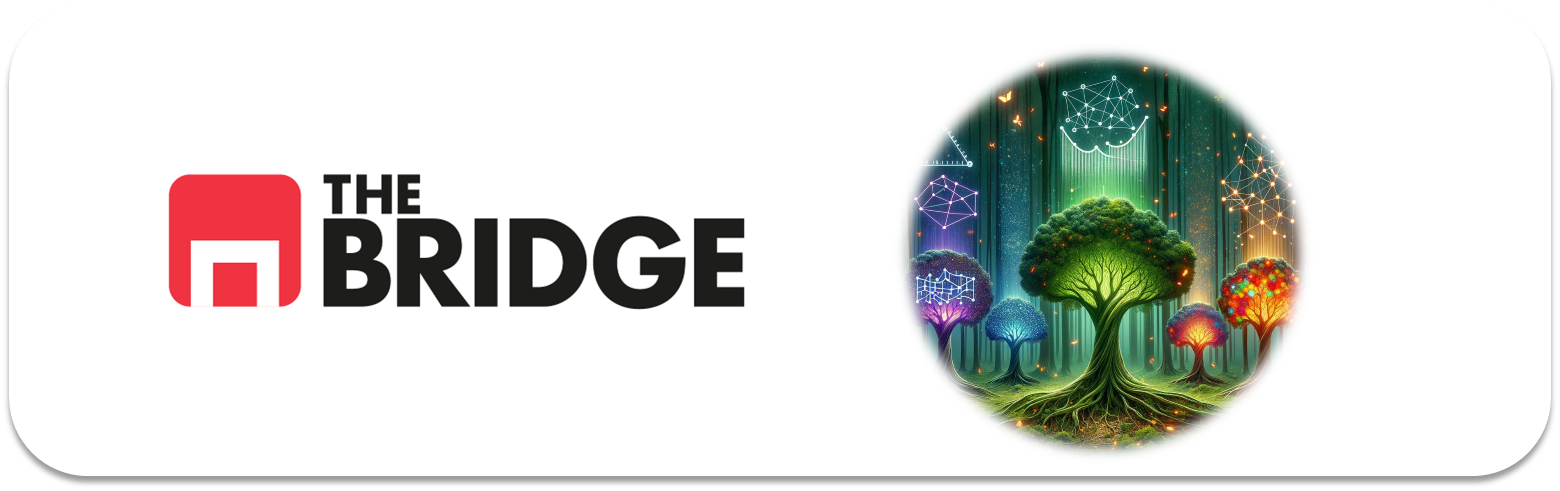

## PRACTICA OBLIGATORIA: **Ensembles: Bagging y Boosting**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de obtención del mejor modelo para la resolución de un problema de clasificación sobre diabetes en la india. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import sklearn.metrics as metrics
import sklearn
import sklearn.datasets as datasets
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor         

### Descripción del dataset

El dataset de los Pima Indians Diabetes contiene datos de un grupo de mujeres de al menos 21 años de edad de ascendencia india Pima que viven cerca de Phoenix, Arizona, EE. UU. Las características del dataset incluyen varios predictores médicos y un objetivo que indica si la paciente desarrolló diabetes dentro de cinco años.

### Características del Dataset

Las variables incluidas en el dataset son:

1. **Número de Embarazos**: Cantidad de veces embarazada.
2. **Concentración de Glucosa en Plasma**: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa.
3. **Presión Arterial Diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del Pliegue Cutáneo del Tríceps**: Grosor del pliegue cutáneo del tríceps (mm).
5. **Insulina en Suero**: Insulina en suero a 2 horas (mu U/ml).
6. **Índice de Masa Corporal**: Peso en kg/(altura en m)^2.
7. **Función del Pedigree de Diabetes**: Una función que representa la predisposición genética a la diabetes.
8. **Edad**: Edad en años.
9. **Variable Objetivo**: Indica si la paciente desarrolló diabetes (1) o no (0).

### Carga de datos

El dataset lo puedes encontrar en la siguiente url y a continuación se proporciona una lista de nombres sugeridos para las columnas:


In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

In [3]:
df_india = pd.read_csv(url, names=names)

In [4]:
df_india.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df_india.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df_india["class"].value_counts(normalize=True)

class
0    0.651042
1    0.348958
Name: proportion, dtype: float64

In [7]:
df_india.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df_india.nunique()

preg      17
plas     136
pres      47
skin      51
test     186
mass     248
pedi     517
age       52
class      2
dtype: int64

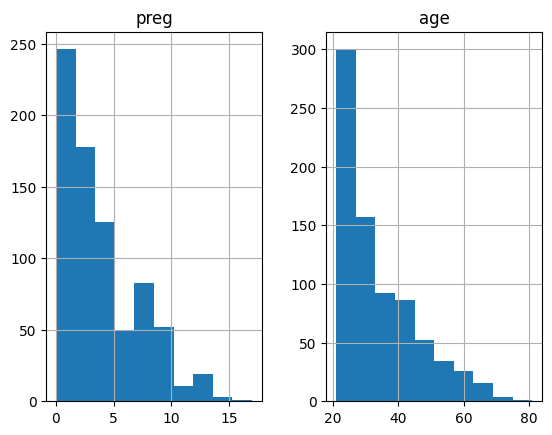

In [9]:
df_india[['preg', 'age']].hist()
plt.show()

In [10]:
df_india['preg'].value_counts()

preg
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
17      1
15      1
Name: count, dtype: int64

In [11]:
target = 'class'

In [12]:
features_num = df_india.columns.to_list()
features_num.remove(target)

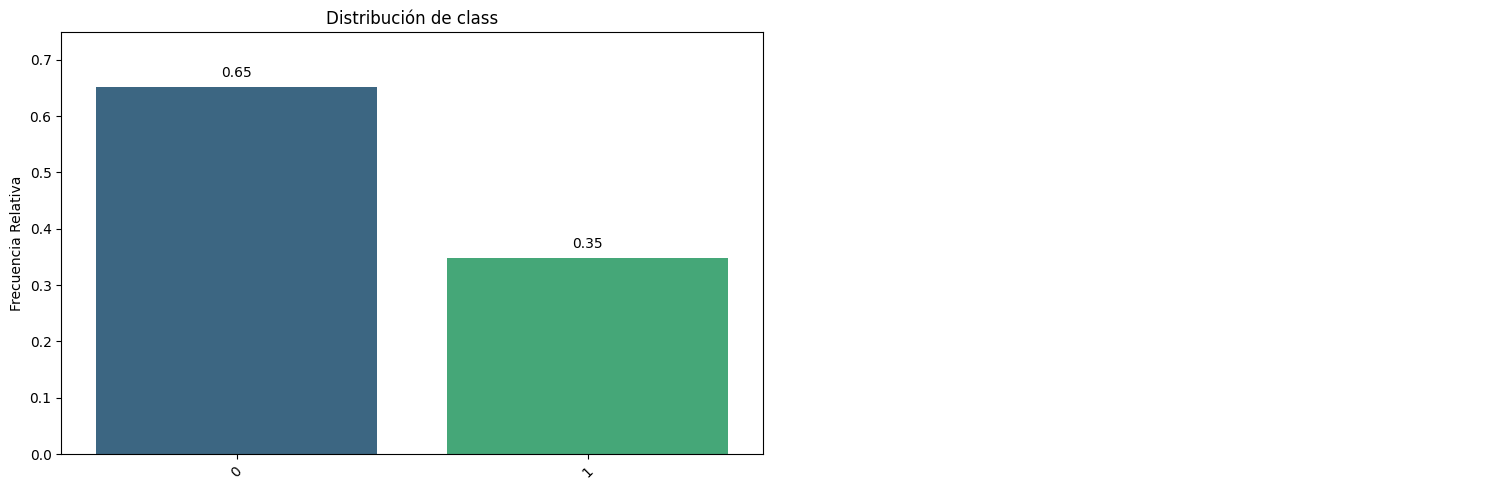

In [13]:
import bootcampviztools as bt

bt.pinta_distribucion_categoricas(df_india, [target], mostrar_valores=True, relativa=True)

In [14]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

In [15]:
train_set, test_set = train_test_split(df_india, test_size=0.2, random_state=73)

In [16]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 544 to 146
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    614 non-null    int64  
 1   plas    614 non-null    int64  
 2   pres    614 non-null    int64  
 3   skin    614 non-null    int64  
 4   test    614 non-null    int64  
 5   mass    614 non-null    float64
 6   pedi    614 non-null    float64
 7   age     614 non-null    int64  
 8   class   614 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 48.0 KB


In [17]:
train_set.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.925081,121.584691,69.475570,20.661238,79.685668,32.072964,0.468743,33.566775,0.353420
std,3.400545,32.852309,18.926454,15.994980,118.668815,7.895084,0.317247,11.964245,0.478422
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,64.000000,0.000000,0.000000,27.400000,0.245000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,7.500000,32.250000,0.372500,29.000000,0.000000
75%,6.000000,141.750000,80.000000,32.000000,126.750000,36.675000,0.617750,41.000000,1.000000
max,17.000000,199.000000,114.000000,99.000000,846.000000,67.100000,2.329000,81.000000,1.000000


In [18]:
#estas columnas tienen ceros
tienen_nulos = ['plas',	'pres',	'skin',	'test',	'mass']

In [19]:
#nan es más fácil de imputar

train_set[tienen_nulos] = train_set[tienen_nulos].replace(0, np.nan)
test_set[tienen_nulos] = test_set[tienen_nulos].replace(0, np.nan)

In [20]:
df_india[tienen_nulos].median()

plas    117.0
pres     72.0
skin     23.0
test     30.5
mass     32.0
dtype: float64

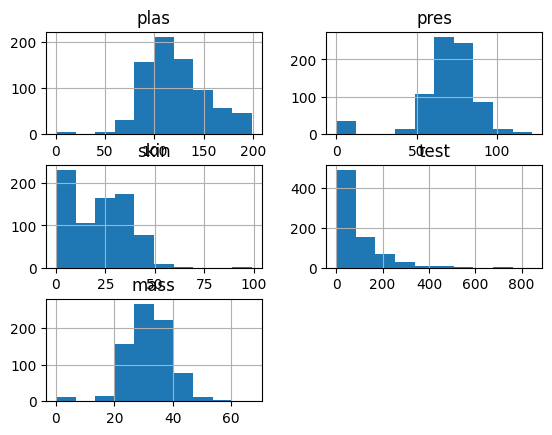

In [21]:
df_india[tienen_nulos].hist()
plt.show()

In [22]:
from sklearn.impute import SimpleImputer
inp = SimpleImputer(strategy='median')

train_set[tienen_nulos] = inp.fit_transform(train_set[tienen_nulos])
test_set[tienen_nulos] = inp.transform(test_set[tienen_nulos])

In [24]:
#compruebo

train_set[tienen_nulos].isnull().sum()

plas    0
pres    0
skin    0
test    0
mass    0
dtype: int64

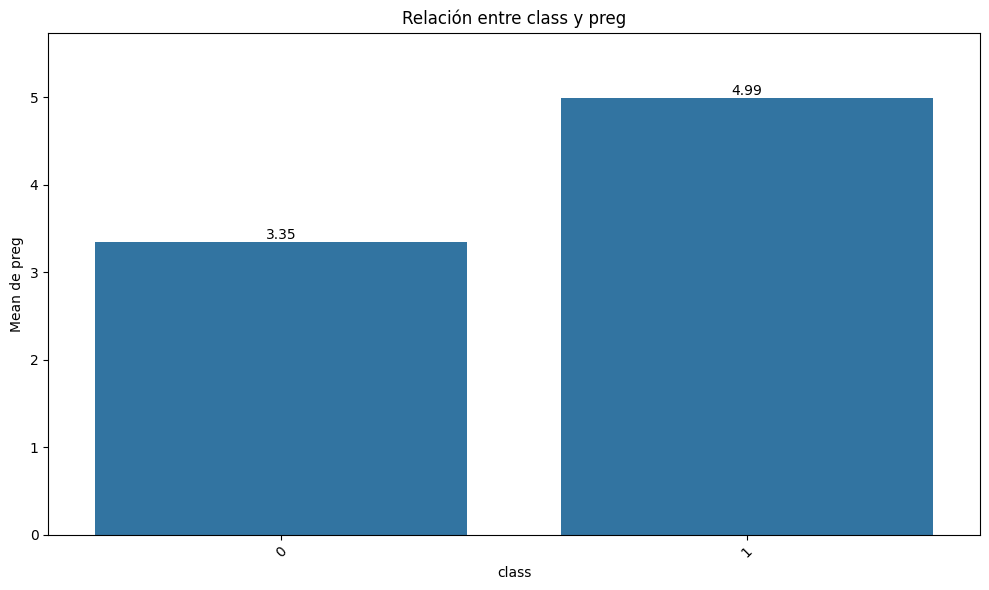

In [ ]:
bt.plot_categorical_numerical_relationship_fin(train_set, target, 'preg', relative_freq=True, show_values=True)

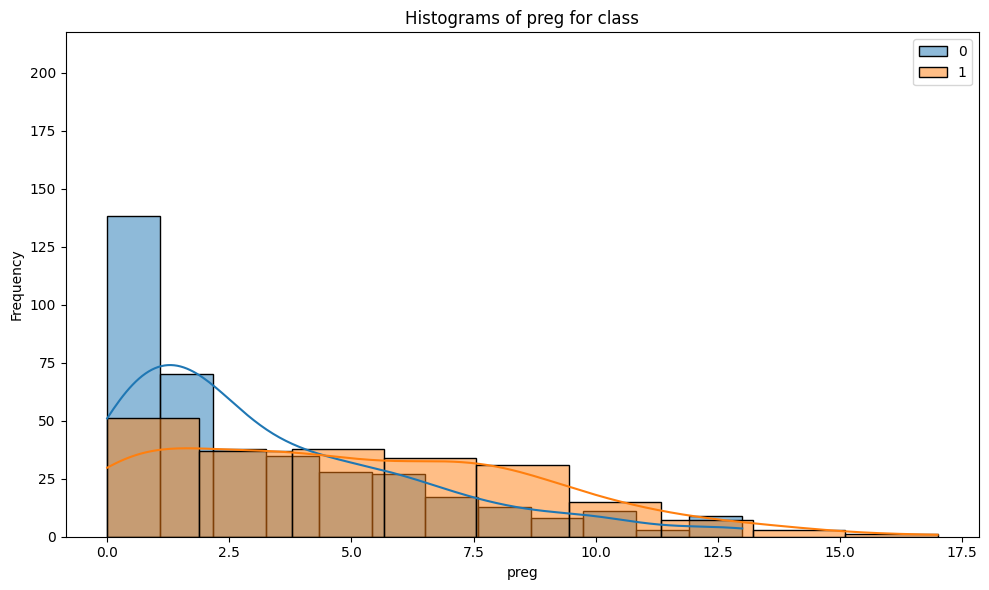

In [28]:
bt.plot_grouped_histograms(train_set, cat_col=target, num_col='preg', group_size=3)

In [29]:
#siguen siendo todas numéricas
features_num

['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']

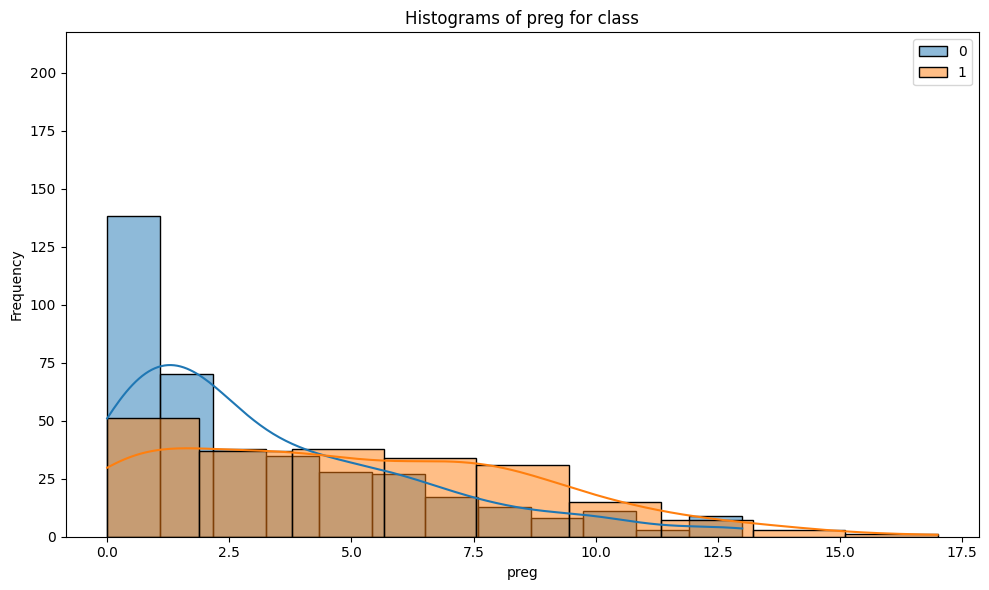

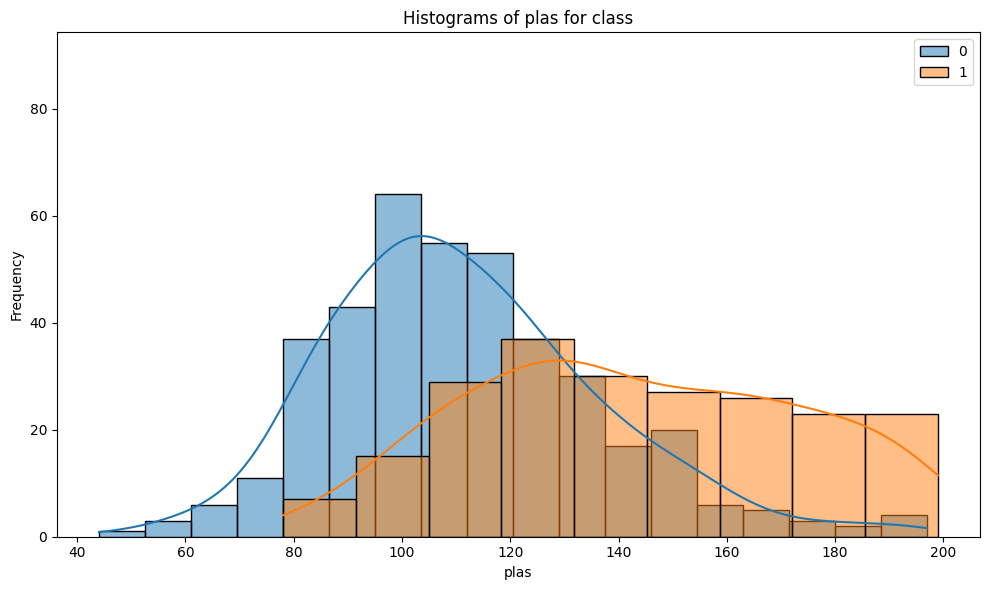

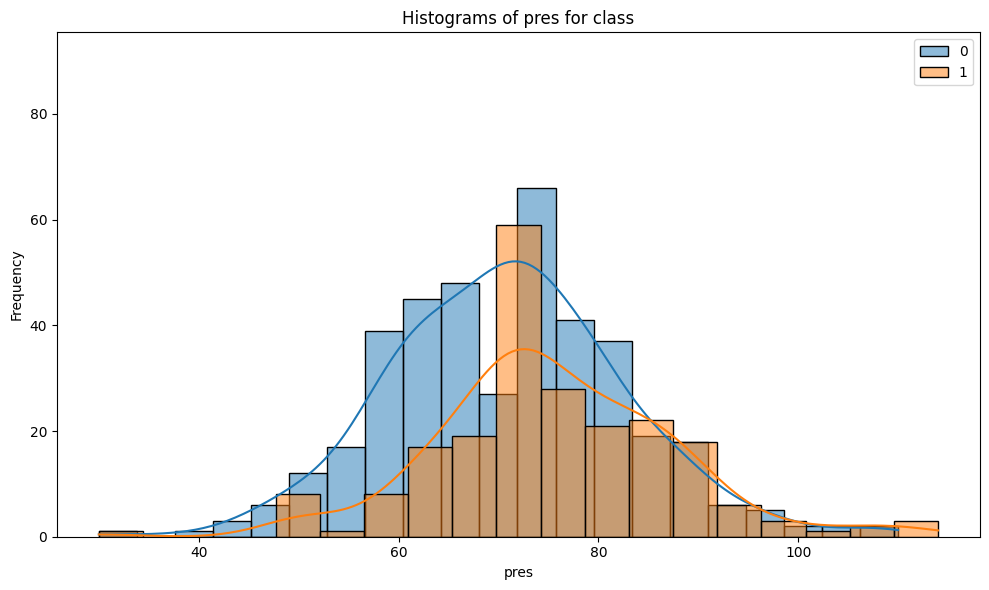

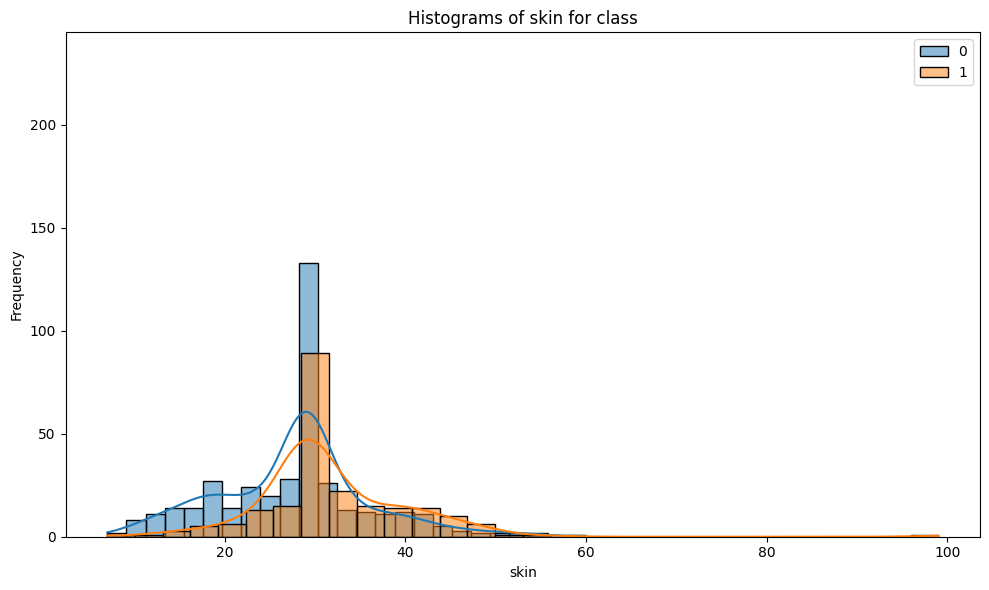

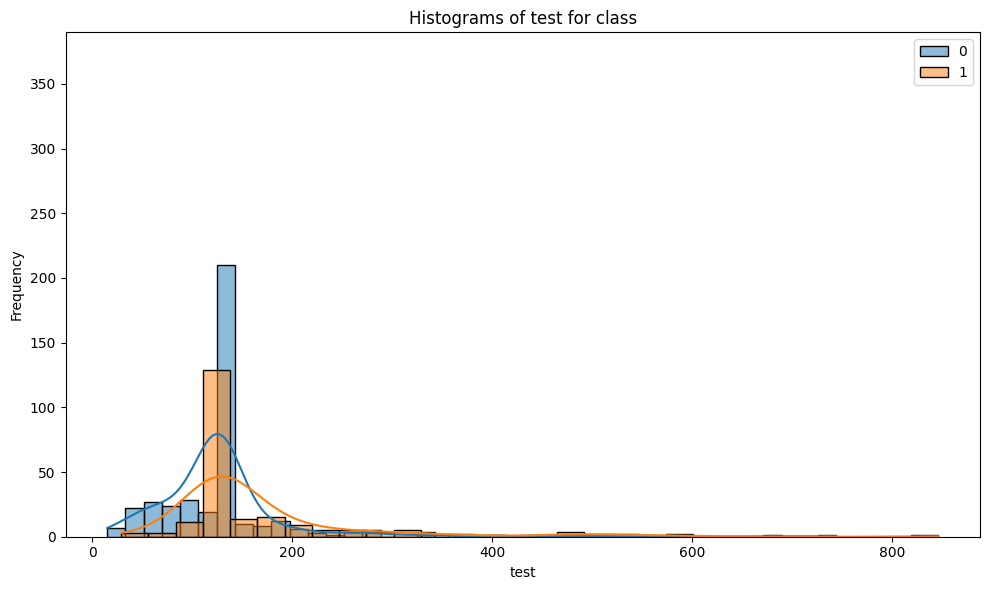

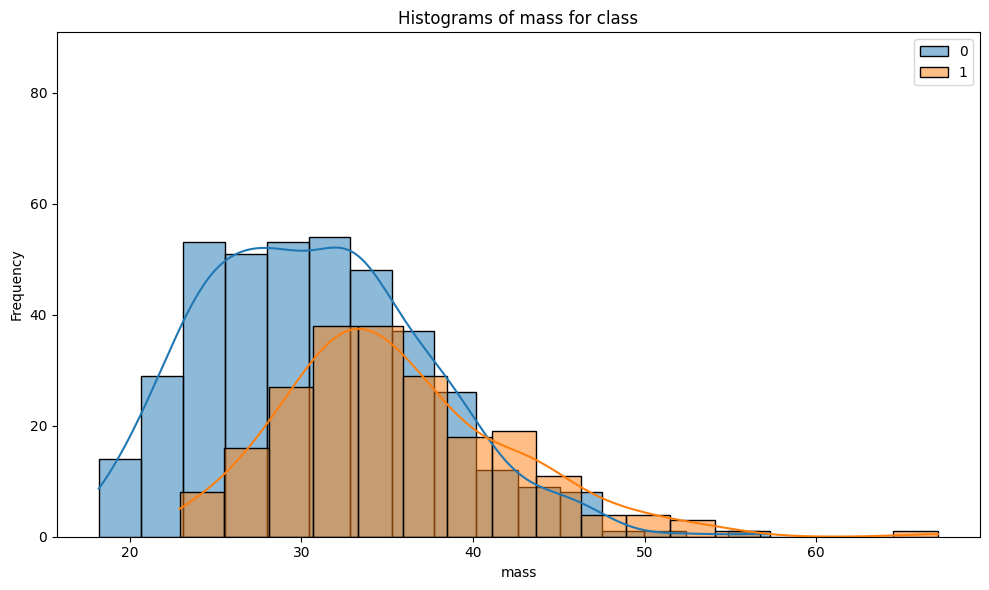

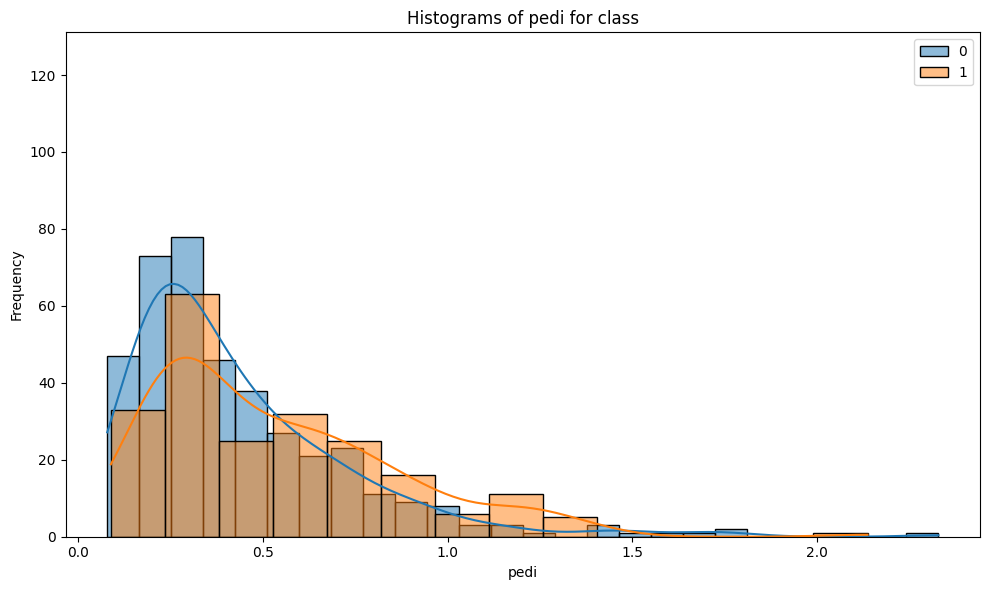

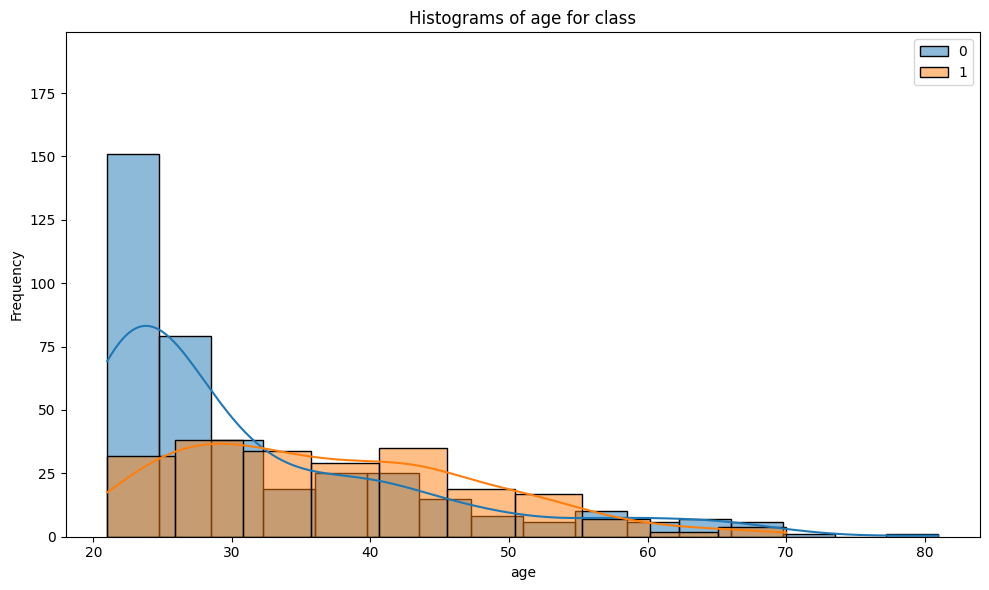

In [30]:
for col in features_num:
    bt.plot_grouped_histograms(train_set, cat_col=target, num_col=col, group_size=3)

In [68]:
x_train = train_set[features_num]
y_train = train_set[target]
x_test = train_set[features_num]
y_test = train_set[target]

In [37]:
#RANDOM FOREST

from sklearn.model_selection import cross_val_score


rf_clf = RandomForestClassifier(max_depth=5, random_state=73)
cross_val_score(rf_clf, x_train, y_train, cv=5, scoring='balanced_accuracy')

array([0.69331395, 0.70406977, 0.72842348, 0.72583429, 0.74433324])

In [39]:
print(f"Random Forest - Recall medio:", np.mean(cross_val_score(rf_clf, x_train, y_train, cv=5, scoring='balanced_accuracy')))

Random Forest - Recall medio: 0.719194944737335


In [41]:
rf_clf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [43]:
print(classification_report(y_train, rf_clf.predict(x_train)))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89       397
           1       0.85      0.71      0.77       217

    accuracy                           0.85       614
   macro avg       0.85      0.82      0.83       614
weighted avg       0.85      0.85      0.85       614



In [44]:
rf_clf.feature_importances_

array([0.06935614, 0.3093857 , 0.04940015, 0.06522226, 0.09159374,
       0.17034078, 0.08162328, 0.16307793])

In [45]:
rf_clf.feature_names_in_

array(['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age'],
      dtype=object)

In [50]:
pd.DataFrame({'Features': rf_clf.feature_names_in_, 'Importance': rf_clf.feature_importances_}).sort_values(by='Importance', ascending=False)

,Features,Importance
1,plas,0.309386
5,mass,0.170341
7,age,0.163078
4,test,0.091594
6,pedi,0.081623
0,preg,0.069356
3,skin,0.065222
2,pres,0.049400


In [55]:
!pip install xgboost



   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.1/101.7 MB 22.7 MB/s eta 0:00:05
   ---- ----------------------------------- 11.3/101.7 MB 37.6 MB/s eta 0:00:03
   ---------- ----------------------------- 26.0/101.7 MB 50.2 MB/s eta 0:00:02
   --------------- ------------------------ 39.1/101.7 MB 54.0 MB/s eta 0:00:02
   -------------------- ------------------- 52.7/101.7 MB 56.5 MB/s eta 0:00:01
   -------------------------- ------------- 66.6/101.7 MB 58.0 MB/s eta 0:00:01
   ------------------------------- -------- 78.9/101.7 MB 57.9 MB/s eta 0:00:01
   ----------------------------------- ---- 90.7/101.7 MB 57.2 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 56.9 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 56.9 MB/s eta 0:00:01
   ---------------------------------------- 101.7/101.7 MB 49.2 MB/s  0:00:02



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 13.7 MB/s  0:00:00



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [59]:
xgboost = XGBClassifier(max_depth=3, random_state=73)
lgboost = LGBMClassifier(max_depth=5, random_state=73, verbose=-1, n_jobs=-1)

In [61]:
for nombre, modelo in zip(['Random Forest', 'XGBoost', 'LGBoost'], [rf_clf, xgboost, lgboost]):
    print(f'Clasificación en entrenamiento para {nombre}:', end=' ')
    print(f"Recall medio:", np.mean(cross_val_score(modelo, x_train, y_train, cv=5, scoring='balanced_accuracy')))


Clasificación en entrenamiento para Random Forest: Recall medio: 0.719194944737335
Clasificación en entrenamiento para XGBoost: Recall medio: 0.6960059009286269
Clasificación en entrenamiento para LGBoost: Recall medio: 0.7014338186100035


In [ ]:
#gana el random
#vamos con el grid

In [63]:
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [1, 2, 4]
}

rf_classsss = RandomForestClassifier()

grid_search = GridSearchCV(rf_classsss,
                           param_grid,
                           cv=5,
                           scoring='balanced_accuracy',
                           n_jobs=-1)

grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displaye

In [64]:
grid_best = grid_search.best_estimator_

In [65]:
grid_search.best_params_

{'max_depth': 7, 'min_samples_leaf': 1, 'n_estimators': 100}

In [66]:
grid_search.best_score_

np.float64(0.7197843351085182)

In [69]:
print(classification_report(y_test, grid_best.predict(x_test)))

              precision    recall  f1-score   support

           0       0.91      0.96      0.94       397
           1       0.92      0.83      0.88       217

    accuracy                           0.92       614
   macro avg       0.92      0.90      0.91       614
weighted avg       0.92      0.92      0.92       614



### Enunciado

Construye el mejor modelo que puedas para predecir a partir de los datos de entrada si una mujer de la tribu Pima desarrollará diabetes. Para ello obtén al menoss tres modelos a partir de tecnologías de bagging y boosting (al menos uno de cada), compáralos sin utilizar el test y selecciona uno de ellos como el mejor (justificándolo). Termina el ejercicio probando el modelo seleccionado y con sus hiperparámetros optimizados contra un dataset de test que deberás haber reservado con anterioridad.

In [ ]:
#RANDOM FOREST CLASSIFIER  sin utiliazar test  BAGGING
from sklearn.model_selection import cross_val_score


rf_clf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)

scores_rf = cross_val_score(rf_clf, x_train, y_train, cv=5, scoring='recall')
print(f"Random Forest - Recall medio: {scores_rf.mean():.4f}")

Random Forest - Recall medio: 0.5068


In [ ]:
#ADA BOSTING CLASSIFIER sin utilizar test

from sklearn.ensemble import AdaBoostClassifier
ab_clf = AdaBoostClassifier(n_estimators=100, random_state=42)
scores_ab = cross_val_score(ab_clf, x_train, y_train, cv=5, scoring='recall')
print(f"AdaBoost - Recall medio: {scores_ab.mean():.4f}")

AdaBoost - Recall medio: 0.6154


In [15]:
#GRADIENT BOOSTING CLASSIFIER sin utilizar test
from sklearn.ensemble import GradientBoostingClassifier
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
scores_gb = cross_val_score(gb_clf, X_train, y_train, cv=5, scoring='recall')
print(f"Gradient Boosting - Recall medio: {scores_gb.mean():.4f}")

Gradient Boosting - Recall medio: 0.6154


ME QUEDO CON GRADIENT BOOTING: minimiza mejor los errores y tiene más hiperparámetros

In [16]:
#GridSearchCV para Gradient Boosting
from sklearn.model_selection import GridSearchCV

In [24]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_samples_leaf': [1, 2, 4]
}


grid_search = GridSearchCV(gb_clf,
                           param_grid,
                           cv=5,
                           scoring='recall',
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [25]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'learning_rate': 0.2, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 200}
0.6483942414174972


In [26]:
#vamos con test ese mejor modelo
mejor_gb = grid_search.best_estimator_
y_pred = mejor_gb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.75      0.77        99
           1       0.60      0.67      0.63        55

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.72      0.72       154



In [23]:
#CONCLUSIÓN



#✅ Tres modelos de ensemble (Random Forest, AdaBoost, Gradient Boosting)
#✅ Comparación sin test con cross_val_score
#✅ Gradient Boosting elegido y justificado
#✅ Optimización con GridSearchCV
#✅ Evaluación final contra test